In [1]:
!pip list | grep -E "numpy|scipy|matplotlib|emcee|corner|astropy|pandas|jupyter"

astropy                 6.1.7
astropy-iers-data       0.2026.7.27.0.56.29
corner                  2.3.0
emcee                   3.1.6
matplotlib              3.10.9
numpy                   2.2.6
pandas                  2.3.3
scipy                   1.15.3


In [2]:
!pip install emcee corner astropy

In [3]:
import pandas as pd

df = pd.read_csv(
    "/home/akanksha/Desktop/Akanksha/Dainotti_evolution/Platinum_sample.csv"
)

df.columns = df.columns.str.strip()

print(df.columns.tolist())

['GRB', 'z', 'log_Tx', 'log_Fx', 'beta_prime', 'F_peak']


In [6]:
import re
import numpy as np
import pandas as pd
from astropy.cosmology import FlatLambdaCDM

cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

df = pd.read_csv(
    "/home/akanksha/Desktop/Akanksha/Dainotti_evolution/Platinum_sample.csv"
)
df.columns = df.columns.str.strip()

def parse_value_errors(s):
    """Parse strings like '3.11887^{+0.05725}_{-0.05724}' or '-9.79296\\pm0.04904'."""
    s = str(s).strip()
    # Pattern: value^{+upper}_{-lower}
    match = re.match(
        r'([+-]?\d+\.?\d*)\^\{([+-]?\d+\.?\d*)\}_\{([+-]?\d+\.?\d*)\}', s
    )
    if match:
        val = float(match.group(1))
        ehi = abs(float(match.group(2)))
        elo = abs(float(match.group(3)))
        err = (ehi + elo) / 2  # symmetrised error
        return val, err
    # Pattern: value\pm uncertainty
    match2 = re.match(r'([+-]?\d+\.?\d*)\\pm(\d+\.?\d*)', s)
    if match2:
        val = float(match2.group(1))
        err = float(match2.group(2))
        return val, err
    # Plain float fallback
    try:
        return float(s), np.nan
    except:
        return np.nan, np.nan

# Parse log_Tx and log_Fx into numeric value + error columns
df[['log_Tx_val', 'log_Tx_err']] = pd.DataFrame(
    df['log_Tx'].apply(parse_value_errors).tolist(), index=df.index
)
df[['log_Fx_val', 'log_Fx_err']] = pd.DataFrame(
    df['log_Fx'].apply(parse_value_errors).tolist(), index=df.index
)

# Sanity check — this should now show clean floats, no NaNs
print(df[['GRB', 'log_Tx_val', 'log_Tx_err', 'log_Fx_val', 'log_Fx_err']].head())
print("\nAny NaNs?")
print(df[['log_Tx_val', 'log_Tx_err', 'log_Fx_val', 'log_Fx_err']].isnull().sum())

# --- Now the physics, using the PARSED numeric columns ---
d_L = cosmo.luminosity_distance(df['z']).to('cm').value

F_X = 10**df['log_Fx_val']          # use the parsed float column, not the raw string one

df['L_X'] = (
    4 * np.pi * d_L**2 * F_X *
    (1 + df['z'])**(df['beta_prime'] - 1)
)
df['log_LX'] = np.log10(df['L_X'])
df['log_TX'] = df['log_Tx_val']

df[['GRB', 'z', 'log_TX', 'log_Fx_val', 'beta_prime', 'log_LX']].head()

      GRB  log_Tx_val  log_Tx_err  log_Fx_val  log_Fx_err
0  060418     3.11887    0.057245    -9.79296     0.04904
1  060605     4.04162    0.037375   -11.26090     0.05315
2  060708     3.50569    0.062725   -10.86880     0.06115
3  060714     3.73449    0.046765   -10.85860     0.03520
4  060814     4.22387    0.034855   -10.91080     0.03530

Any NaNs?
log_Tx_val    0
log_Tx_err    0
log_Fx_val    0
log_Fx_err    0
dtype: int64


,GRB,z,log_TX,log_Fx_val,beta_prime,log_LX
0,060418,1.49,3.11887,-9.79296,1.980,48.741676
1,060605,3.80,4.04162,-11.26090,1.835,48.441939
2,060708,1.92,3.50569,-10.86880,2.485,48.239648
3,060714,2.71,3.73449,-10.85860,1.870,48.418615
4,060814,0.84,4.22387,-10.91080,1.970,46.877167


In [7]:
import os

print("Current working directory:", os.getcwd())
print(os.listdir())

Current working directory: /home/akanksha/tle-project/Dainotti_evolution
['.ipynb_checkpoints', 'dainotti_evolution.ipynb', 'figures']


In [8]:
import sys
print(sys.executable)
print(sys.version)

/home/akanksha/.local/share/pipx/venvs/notebook/bin/python
3.12.3 (main, Mar 23 2026, 19:04:32) [GCC 13.3.0]


In [9]:
!which python
!which pip
!pip --version

/home/akanksha/Siesta_5/miniconda3/bin/python
/home/akanksha/Siesta_5/miniconda3/bin/pip
pip 25.3 from /home/akanksha/Siesta_5/miniconda3/lib/python3.10/site-packages/pip (python 3.10)


In [6]:
!pip install numpy scipy matplotlib emcee corner astropy pandas

In [10]:
import os
os.listdir("/home/akanksha/Desktop/Akanksha/Dainotti_evolution")

['CosmoManual: Chapter1_The_Expanding_Universe.pdf', 'Platinum_sample.csv']

In [8]:
import sys
!{sys.executable} -m pip install numpy scipy pandas matplotlib astropy emcee corner


[notice] A new release of pip is available: 25.3 -> 26.2
[notice] To update, run: /home/akanksha/.local/share/pipx/venvs/notebook/bin/python -m pip install --upgrade pip


In [11]:
print(df.columns.tolist())

['GRB', 'z', 'log_Tx', 'log_Fx', 'beta_prime', 'F_peak', 'log_Tx_val', 'log_Tx_err', 'log_Fx_val', 'log_Fx_err', 'L_X', 'log_LX', 'log_TX']


In [12]:
print(df.head())
print("\nData types:")
print(df.dtypes)
print("\nBasic stats:")
print(df.describe())

      GRB     z                         log_Tx                        log_Fx  \
0  060418  1.49  3.11887^{+0.05725}_{-0.05724}            -9.79296\pm0.04904   
1  060605  3.80  4.04162^{+0.03738}_{-0.03737}  -11.2609^{+0.0531}_{-0.0532}   
2  060708  1.92  3.50569^{+0.06273}_{-0.06272}  -10.8688^{+0.0611}_{-0.0612}   
3  060714  2.71  3.73449^{+0.04676}_{-0.04677}             -10.8586\pm0.0352   
4  060814  0.84  4.22387^{+0.03485}_{-0.03486}             -10.9108\pm0.0353   

   beta_prime        F_peak  log_Tx_val  log_Tx_err  log_Fx_val  log_Fx_err  \
0       1.980   49.9\pm1.63     3.11887    0.057245    -9.79296     0.04904   
1       1.835  4.73\pm0.693     4.04162    0.037375   -11.26090     0.05315   
2       2.485  6.89\pm0.796     3.50569    0.062725   -10.86880     0.06115   
3       1.870  9.13\pm0.549     3.73449    0.046765   -10.85860     0.03520   
4       1.970   60.6\pm1.48     4.22387    0.034855   -10.91080     0.03530   

            L_X     log_LX   log_TX  
0  5.5

In [13]:
print(df.shape)  # should be 50 rows
print(df.isnull().sum())  # check for missing values

(50, 13)
GRB           0
z             0
log_Tx        0
log_Fx        0
beta_prime    0
F_peak        0
log_Tx_val    0
log_Tx_err    0
log_Fx_val    0
log_Fx_err    0
L_X           0
log_LX        0
log_TX        0
dtype: int64


In [14]:
import re
import numpy as np
import pandas as pd

def parse_value_errors(s):
    """Parse strings like '3.11887^{+0.05725}_{-0.05724}' """
    s = str(s).strip()
    # Pattern: value^{+upper}_{-lower}
    match = re.match(
        r'([+-]?\d+\.?\d*)\^\{([+-]?\d+\.?\d*)\}_\{([+-]?\d+\.?\d*)\}', s
    )
    if match:
        val  = float(match.group(1))
        ehi  = abs(float(match.group(2)))
        elo  = abs(float(match.group(3)))
        err  = (ehi + elo) / 2  # symmetrised error
        return val, err
    # Pattern: value\pmuncertainty
    match2 = re.match(r'([+-]?\d+\.?\d*)\\pm(\d+\.?\d*)', s)
    if match2:
        val = float(match2.group(1))
        err = float(match2.group(2))
        return val, err
    # Plain float fallback
    try:
        return float(s), np.nan
    except:
        return np.nan, np.nan

# Parse log_Tx
df[['log_Tx_val', 'log_Tx_err']] = pd.DataFrame(
    df['log_Tx'].apply(parse_value_errors).tolist(), index=df.index
)

# Parse log_Fx
df[['log_Fx_val', 'log_Fx_err']] = pd.DataFrame(
    df['log_Fx'].apply(parse_value_errors).tolist(), index=df.index
)

# Parse F_peak
df[['F_peak_val', 'F_peak_err']] = pd.DataFrame(
    df['F_peak'].apply(parse_value_errors).tolist(), index=df.index
)

# Verify
print(df[['z', 'log_Tx_val', 'log_Tx_err',
          'log_Fx_val', 'log_Fx_err',
          'beta_prime']].head(10))
print("\nAny NaNs?")
print(df[['log_Tx_val','log_Tx_err','log_Fx_val','log_Fx_err']].isnull().sum())

        z  log_Tx_val  log_Tx_err  log_Fx_val  log_Fx_err  beta_prime
0  1.4900     3.11887    0.057245    -9.79296     0.04904      1.9800
1  3.8000     4.04162    0.037375   -11.26090     0.05315      1.8350
2  1.9200     3.50569    0.062725   -10.86880     0.06115      2.4850
3  2.7100     3.73449    0.046765   -10.85860     0.03520      1.8700
4  0.8400     4.22387    0.034855   -10.91080     0.03530      1.9700
5  3.6850     4.33479    0.072145   -11.88330     0.08845      2.0600
6  1.3140     3.78753    0.017030   -10.02990     0.01265      1.9485
7  2.0880     3.92091    0.024435    -9.95369     0.02311      1.8600
8  2.3520     4.26825    0.053995   -11.04880     0.05475      2.1860
9  1.4959     4.86926    0.028240   -11.27370     0.03350      1.8310

Any NaNs?
log_Tx_val    0
log_Tx_err    0
log_Fx_val    0
log_Fx_err    0
dtype: int64


In [15]:
from astropy.cosmology import FlatLambdaCDM
import numpy as np

# Fiducial cosmology — circularity caveat applies here (noted in write-up)
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# Luminosity distance in cm
d_L_cm = cosmo.luminosity_distance(df['z']).to('cm').value

# L_X formula: L_X = 4π d_L² · F_X · (1+z)^(β-1)
# In log space: log_LX = log(4π) + 2·log(d_L) + log_Fx + (β-1)·log(1+z)
df['log_LX'] = (
    np.log10(4 * np.pi)
    + 2 * np.log10(d_L_cm)
    + df['log_Fx_val']
    + (df['beta_prime'] - 1) * np.log10(1 + df['z'])
)

# Error propagation in log space
# Only log_Fx and log_Tx have measurement errors in this dataset
# beta_prime has no listed error — treat as fixed (standard in literature)
df['sigma_logLX'] = df['log_Fx_err']   # dominant term
df['sigma_logTX'] = df['log_Tx_err']

# Quick sanity check
print(df[['z', 'log_LX', 'sigma_logLX', 'log_Tx_val', 'sigma_logTX']].head(10))
print(f"\nlog_LX range: {df['log_LX'].min():.2f} to {df['log_LX'].max():.2f}")
print(f"log_Tx range: {df['log_Tx_val'].min():.2f} to {df['log_Tx_val'].max():.2f}")

        z     log_LX  sigma_logLX  log_Tx_val  sigma_logTX
0  1.4900  48.741676      0.04904     3.11887     0.057245
1  3.8000  48.441939      0.05315     4.04162     0.037375
2  1.9200  48.239648      0.06115     3.50569     0.062725
3  2.7100  48.418615      0.03520     3.73449     0.046765
4  0.8400  46.877167      0.03530     4.22387     0.034855
5  3.6850  47.929880      0.08845     4.33479     0.072145
6  1.3140  48.327145      0.01265     3.78753     0.017030
7  2.0880  48.973969      0.02311     3.92091     0.024435
8  2.3520  48.206839      0.05475     4.26825     0.053995
9  1.4959  47.206993      0.03350     4.86926     0.028240

log_LX range: 46.88 to 50.43
log_Tx range: 2.49 to 4.87


In [16]:
import os
os.makedirs('figures', exist_ok=True)

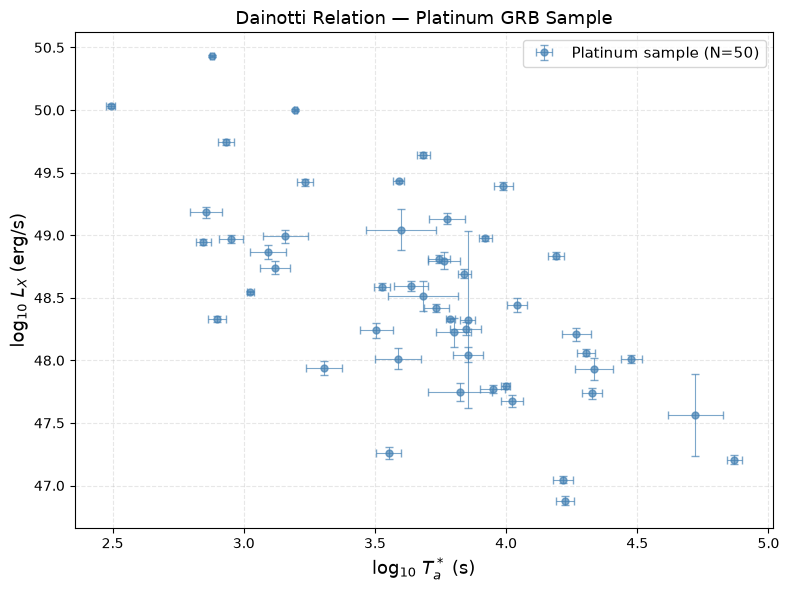

Figure 1 saved.


In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

ax.errorbar(
    df['log_Tx_val'], df['log_LX'],
    xerr=df['sigma_logTX'], yerr=df['sigma_logLX'],
    fmt='o', color='steelblue', alpha=0.7,
    capsize=3, markersize=5, linewidth=0.8,
    label='Platinum sample (N=50)'
)

ax.set_xlabel(r'$\log_{10}\, T_a^*$ (s)', fontsize=13)
ax.set_ylabel(r'$\log_{10}\, L_X$ (erg/s)', fontsize=13)
ax.set_title('Dainotti Relation — Platinum GRB Sample', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('figures/fig1_full_sample.pdf', bbox_inches='tight', dpi=150)
plt.savefig('figures/fig1_full_sample.png', bbox_inches='tight', dpi=150)
plt.show()

print("Figure 1 saved.")

In [18]:
import emcee
import numpy as np

def log_likelihood(theta, x, y, xerr, yerr):
    a, C0, log_sigma = theta
    sigma_int = 10**log_sigma
    
    # Total variance: measurement errors on both axes + intrinsic scatter
    sigma_tot2 = yerr**2 + (a * xerr)**2 + sigma_int**2
    
    residuals = y - (C0 + a * x)
    
    # D'Agostini likelihood — penalty term prevents sigma_int inflating freely
    return -0.5 * np.sum(residuals**2 / sigma_tot2 + np.log(sigma_tot2))

def log_prior(theta):
    a, C0, log_sigma = theta
    if -3.0 < a < 0.0 and 40.0 < C0 < 60.0 and -2.0 < log_sigma < 2.0:
        return 0.0
    return -np.inf

def log_posterior(theta, x, y, xerr, yerr):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, x, y, xerr, yerr)

print("Likelihood, prior, posterior defined.")

Likelihood, prior, posterior defined.


In [19]:
import sys
import subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "tqdm"], check=True)


[notice] A new release of pip is available: 25.3 -> 26.2
[notice] To update, run: /home/akanksha/.local/share/pipx/venvs/notebook/bin/python -m pip install --upgrade pip


CompletedProcess(args=['/home/akanksha/.local/share/pipx/venvs/notebook/bin/python', '-m', 'pip', 'install', 'tqdm'], returncode=0)

In [20]:
import importlib
import tqdm
importlib.reload(tqdm)

import emcee
import numpy as np

# Data arrays
x    = df['log_Tx_val'].values
y    = df['log_LX'].values
xerr = df['sigma_logTX'].values
yerr = df['sigma_logLX'].values

p0_center = np.array([-1.0, 52.0, np.log10(0.4)])
ndim, nwalkers = 3, 32

rng = np.random.default_rng(42)
p0 = p0_center + rng.normal(0, 0.01, size=(nwalkers, ndim))

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_posterior,
    args=(x, y, xerr, yerr)
)

print("Running burn-in (500 steps)...")
state = sampler.run_mcmc(p0, 500, progress=True)
sampler.reset()

print("Running production (5000 steps)...")
sampler.run_mcmc(state, 5000, progress=True)

flat_samples = sampler.get_chain(flat=True)
print(f"\nTotal posterior samples: {flat_samples.shape[0]}")

Running burn-in (500 steps)...


100%|█████████████████████████████████| 500/500 [00:00<00:00, 631.97it/s]


Running production (5000 steps)...


100%|███████████████████████████████| 5000/5000 [00:07<00:00, 713.35it/s]


Total posterior samples: 160000


In [30]:
labels = ['a', 'C0', 'log_sigma_int']

print("=" * 50)
print("BASELINE FIT — Full Platinum Sample (N=50)")
print("=" * 50)

results_global = {}
for i, label in enumerate(labels):
    q16, q50, q84 = np.percentile(flat_samples[:, i], [16, 50, 84])
    results_global[label] = (q50, q50 - q16, q84 - q50)
    print(f"{label:20s} = {q50:.4f}  +{q84-q50:.4f}  -{q50-q16:.4f}")

sigma_int_median = 10**results_global['log_sigma_int'][0]
print(f"\nsigma_int (linear)   = {sigma_int_median:.3f} dex")

print()
print("Literature comparison:")
print(f"  Cao et al. 2022a :  a ≈ -1.04,  C0 ≈ 52.0,  sigma_int ≈ 0.40")
print(f"  Dainotti et al. 2010 (2-param, X-ray): a ≈ -1.06 ± 0.27")
print("  Note: Cao et al. value is from a 3-parameter fit (incl. L_peak);")
print("  this work uses a 2-parameter model, so treat as context, not strict validation.")
print(f"  This work        :  a = {results_global['a'][0]:.3f}")

BASELINE FIT — Full Platinum Sample (N=50)
a                    = -0.9728  +0.1653  -0.1670
C0                   = 52.0972  +0.6206  -0.6133
log_sigma_int        = -0.2184  +0.0464  -0.0440

sigma_int (linear)   = 0.605 dex

Literature comparison:
  Cao et al. 2022a :  a ≈ -1.04,  C0 ≈ 52.0,  sigma_int ≈ 0.40
  Dainotti et al. 2010 (2-param, X-ray): a ≈ -1.06 ± 0.27
  Note: Cao et al. value is from a 3-parameter fit (incl. L_peak);
  this work uses a 2-parameter model, so treat as context, not strict validation.
  This work        :  a = -0.973


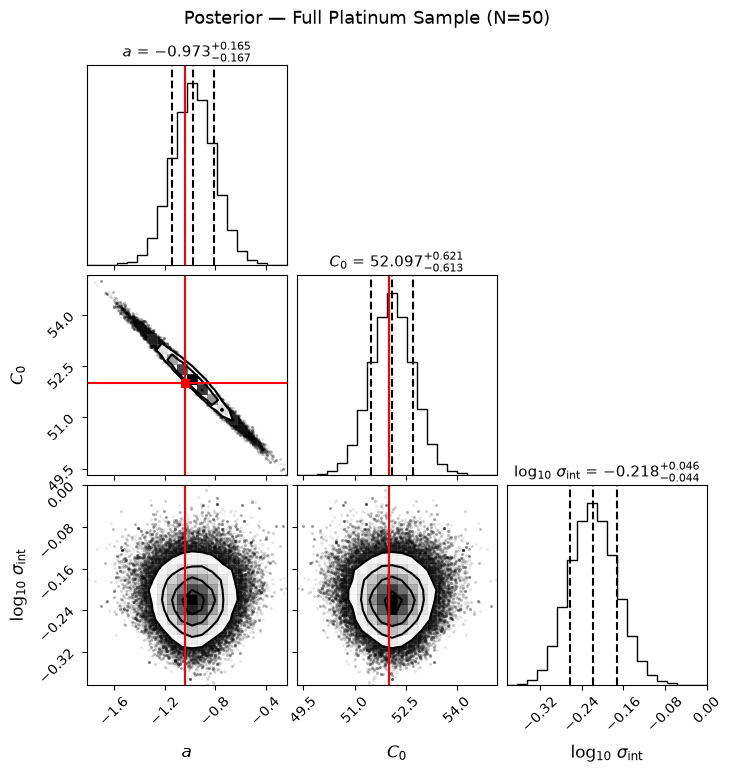

Figure 2 saved.


In [22]:
import corner

fig = corner.corner(
    flat_samples,
    labels=[r'$a$', r'$C_0$', r'$\log_{10}\,\sigma_\mathrm{int}$'],
    quantiles=[0.16, 0.50, 0.84],
    show_titles=True,
    title_fmt='.3f',
    title_kwargs={"fontsize": 11},
    label_kwargs={"fontsize": 12},
    truths=[-1.04, 52.0, np.log10(0.40)],  # literature values as reference
    truth_color='red'
)

fig.suptitle('Posterior — Full Platinum Sample (N=50)', 
             fontsize=13, y=1.02)
fig.savefig('figures/fig2_corner_fullsample.pdf', bbox_inches='tight', dpi=150)
fig.savefig('figures/fig2_corner_fullsample.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure 2 saved.")

In [23]:
# Sort by redshift
df_sorted = df.sort_values('z').reset_index(drop=True)

# Equal-number bins — ~16-17 GRBs each
n = len(df_sorted)
bin_edges = [0, n//3, 2*n//3, n]

bins = []
for i in range(3):
    b = df_sorted.iloc[bin_edges[i]:bin_edges[i+1]].copy()
    bins.append(b)
    print(f"Bin {i+1}: N={len(b):2d} | "
          f"z = [{b['z'].min():.3f}, {b['z'].max():.3f}] | "
          f"z_median = {b['z'].median():.3f}")

Bin 1: N=16 | z = [0.553, 1.710] | z_median = 1.302
Bin 2: N=17 | z = [1.758, 2.500] | z_median = 2.088
Bin 3: N=17 | z = [2.600, 5.000] | z_median = 3.360


In [24]:
def fit_bin(bin_df, label="", nwalkers=32, nburn=500, nprod=3000):
    x    = bin_df['log_Tx_val'].values
    y    = bin_df['log_LX'].values
    xerr = bin_df['sigma_logTX'].values
    yerr = bin_df['sigma_logLX'].values

    p0_center = np.array([-1.0, 52.0, np.log10(0.4)])
    rng = np.random.default_rng(42)
    p0 = p0_center + rng.normal(0, 0.05, size=(nwalkers, 3))

    sampler = emcee.EnsembleSampler(
        nwalkers, 3, log_posterior,
        args=(x, y, xerr, yerr)
    )

    state = sampler.run_mcmc(p0, nburn, progress=False)
    sampler.reset()
    sampler.run_mcmc(state, nprod, progress=False)

    flat = sampler.get_chain(flat=True)

    result = {'z_median': bin_df['z'].median(), 'samples': flat}
    for i, name in enumerate(['a', 'C0', 'log_sigma']):
        q16, q50, q84 = np.percentile(flat[:, i], [16, 50, 84])
        result[name]         = q50
        result[f'{name}_lo'] = q50 - q16
        result[f'{name}_hi'] = q84 - q50

    print(f"\n{label}")
    print(f"  z_median = {result['z_median']:.3f}")
    print(f"  a        = {result['a']:.4f}  +{result['a_hi']:.4f}  -{result['a_lo']:.4f}")
    print(f"  C0       = {result['C0']:.4f}  +{result['C0_hi']:.4f}  -{result['C0_lo']:.4f}")
    print(f"  sigma_int= {10**result['log_sigma']:.3f} dex")

    return result

print("Running per-bin MCMC fits (3 bins × ~3000 steps, takes 3-5 mins)...")
bin_results = []
for i, (b, label) in enumerate(zip(bins, ['Bin 1 (low-z)', 'Bin 2 (mid-z)', 'Bin 3 (high-z)'])):
    r = fit_bin(b, label=label)
    bin_results.append(r)

print("\nAll bins done.")

Running per-bin MCMC fits (3 bins × ~3000 steps, takes 3-5 mins)...

Bin 1 (low-z)
  z_median = 1.302
  a        = -0.9007  +0.2233  -0.2197
  C0       = 51.3305  +0.8062  -0.8143
  sigma_int= 0.485 dex

Bin 2 (mid-z)
  z_median = 2.088
  a        = -1.0708  +0.2355  -0.2260
  C0       = 52.5409  +0.8256  -0.8614
  sigma_int= 0.531 dex

Bin 3 (high-z)
  z_median = 3.360
  a        = -1.3367  +0.2921  -0.3005
  C0       = 53.8660  +1.1475  -1.1124
  sigma_int= 0.457 dex

All bins done.


In [25]:
import scipy.stats

a_vals = np.array([r['a'] for r in bin_results])
a_errs = np.array([(r['a_lo'] + r['a_hi'])/2 for r in bin_results])
z_meds = np.array([r['z_median'] for r in bin_results])

# Weighted mean
weights = 1.0 / a_errs**2
a_bar   = np.sum(weights * a_vals) / np.sum(weights)

# Chi-squared
chi2 = np.sum((a_vals - a_bar)**2 / a_errs**2)
dof  = len(bins) - 1  # = 2
pval = 1 - scipy.stats.chi2.cdf(chi2, dof)

print("=" * 50)
print("CHI-SQUARED CONSISTENCY TEST")
print("=" * 50)
print(f"Weighted mean slope : a_bar = {a_bar:.4f}")
print(f"Chi2                = {chi2:.3f}")
print(f"dof                 = {dof}")
print(f"Chi2/dof            = {chi2/dof:.3f}")
print(f"p-value             = {pval:.4f}")
print()
if chi2/dof > 2:
    print(">> Slopes are INCONSISTENT beyond measurement errors.")
    print(">> Suggests redshift evolution — but see caveats.")
elif chi2/dof > 1:
    print(">> Mild tension between bins. Suggestive but not conclusive.")
else:
    print(">> Slopes mutually consistent. No significant evolution detected.")

CHI-SQUARED CONSISTENCY TEST
Weighted mean slope : a_bar = -1.0621
Chi2                = 1.391
dof                 = 2
Chi2/dof            = 0.696
p-value             = 0.4988

>> Slopes mutually consistent. No significant evolution detected.


LINEAR DRIFT FIT  a(z) = a0 + a1·z
a0 (intercept) = -0.6267
a1 (slope)     = -0.2116 ± 0.0020
r²             = 0.9999
p-value        = 0.0060

CAUTION: this fit has only 1 degree of freedom (3 points, 2 parameters).
A line fits any 3 points almost perfectly regardless of real structure,
so the small formal standard error above is not a meaningful significance
estimate. This fit is shown for illustration only.

The chi-squared test (previous cell) is the statistically valid result:
>> chi2/dof = 0.696, p = 0.4988 — slopes mutually consistent,
>> no significant evolution detected.


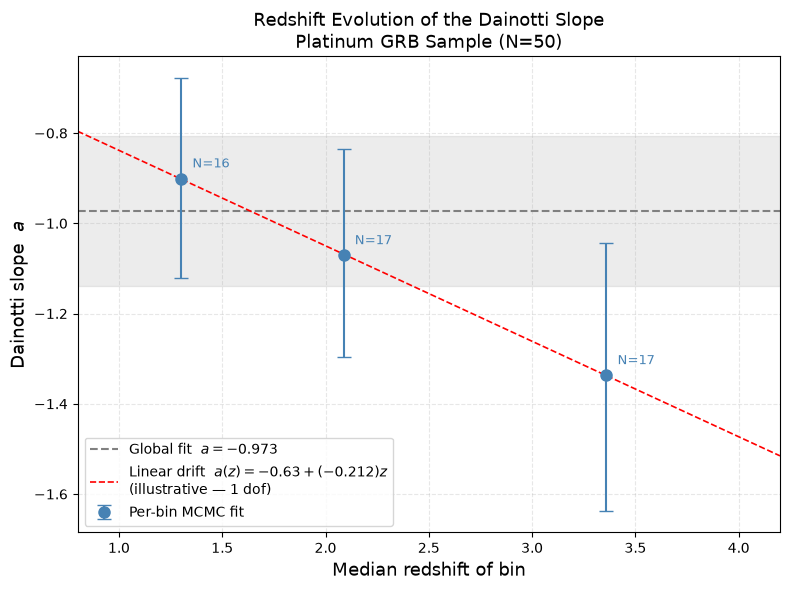

Figure 3 saved.


In [26]:
from scipy.stats import linregress
import matplotlib.pyplot as plt

# Linear drift fit across 3 bin medians
a_lo = np.array([r['a_lo'] for r in bin_results])
a_hi = np.array([r['a_hi'] for r in bin_results])

slope_fit, intercept_fit, r_val, p_val_lin, se = linregress(z_meds, a_vals)

print("="*50)
print("LINEAR DRIFT FIT  a(z) = a0 + a1·z")
print("="*50)
print(f"a0 (intercept) = {intercept_fit:.4f}")
print(f"a1 (slope)     = {slope_fit:.4f} ± {se:.4f}")
print(f"r²             = {r_val**2:.4f}")
print(f"p-value        = {p_val_lin:.4f}")
print()
print("CAUTION: this fit has only 1 degree of freedom (3 points, 2 parameters).")
print("A line fits any 3 points almost perfectly regardless of real structure,")
print("so the small formal standard error above is not a meaningful significance")
print("estimate. This fit is shown for illustration only.")
print()
print("The chi-squared test (previous cell) is the statistically valid result:")
print(f">> chi2/dof = {chi2/dof:.3f}, p = {pval:.4f} — slopes mutually consistent,")
print(">> no significant evolution detected.")

# Figure 3
z_line = np.linspace(0.8, 4.2, 100)

fig, ax = plt.subplots(figsize=(8, 6))

# Global fit reference band
a_global     = results_global['a'][0]
a_global_err = (results_global['a'][1] + results_global['a'][2]) / 2

ax.axhline(a_global, color='gray', linestyle='--', linewidth=1.5,
           label=f'Global fit  $a = {a_global:.3f}$')
ax.fill_between([0.8, 4.2],
                a_global - a_global_err,
                a_global + a_global_err,
                alpha=0.15, color='gray')

# Linear drift line
ax.plot(z_line, intercept_fit + slope_fit * z_line,
        'r--', linewidth=1.2,
        label=f'Linear drift  $a(z) = {intercept_fit:.2f} + ({slope_fit:.3f})z$\n(illustrative — 1 dof)')

# Per-bin measurements
ax.errorbar(z_meds, a_vals,
            yerr=[a_lo, a_hi],
            fmt='o', color='steelblue', capsize=5,
            markersize=8, linewidth=1.5,
            label='Per-bin MCMC fit')

# Bin redshift ranges as horizontal error bars
for i, r in enumerate(bin_results):
    ax.annotate(f'N={len(bins[i])}',
                xy=(z_meds[i], a_vals[i]),
                xytext=(8, 8), textcoords='offset points',
                fontsize=9, color='steelblue')

ax.set_xlabel('Median redshift of bin', fontsize=13)
ax.set_ylabel('Dainotti slope  $a$', fontsize=13)
ax.set_title('Redshift Evolution of the Dainotti Slope\n'
             'Platinum GRB Sample (N=50)', fontsize=13)
ax.legend(fontsize=10, loc='lower left')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlim(0.8, 4.2)

plt.tight_layout()
plt.savefig('figures/fig3_slope_evolution.pdf', bbox_inches='tight', dpi=150)
plt.savefig('figures/fig3_slope_evolution.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure 3 saved.")

RMS residual — global fit : 0.5849 dex
RMS residual — local fit  : 0.4557 dex
Reduction in RMS          : 22.1%


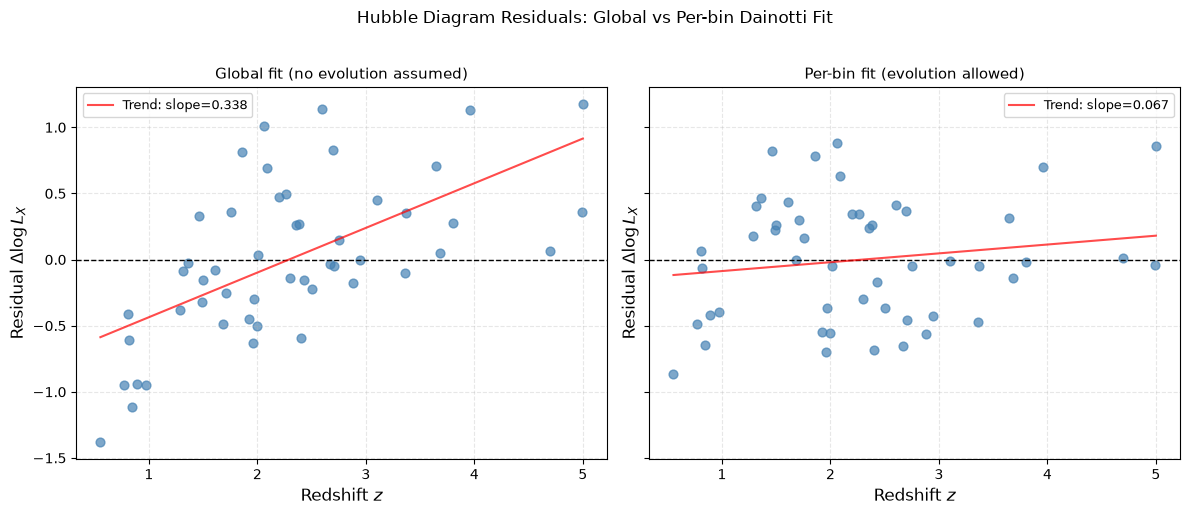

Figure 5 saved.


In [27]:
# Assign each GRB its bin's slope and intercept
df_sorted['bin_idx'] = -1
for i in range(3):
    df_sorted.loc[bins[i].index, 'bin_idx'] = i

df_sorted['a_local']  = df_sorted['bin_idx'].map(
    {i: bin_results[i]['a']  for i in range(3)}
)
df_sorted['C0_local'] = df_sorted['bin_idx'].map(
    {i: bin_results[i]['C0'] for i in range(3)}
)

# Global parameters
a_global_val  = results_global['a'][0]
C0_global_val = results_global['C0'][0]

# Residuals: observed minus predicted log_LX
df_sorted['resid_global'] = (df_sorted['log_LX']
    - (C0_global_val + a_global_val * df_sorted['log_Tx_val']))

df_sorted['resid_local']  = (df_sorted['log_LX']
    - (df_sorted['C0_local'] + df_sorted['a_local'] * df_sorted['log_Tx_val']))

# Figure 5 — residuals comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, col, title in zip(
    axes,
    ['resid_global', 'resid_local'],
    ['Global fit (no evolution assumed)',
     'Per-bin fit (evolution allowed)']
):
    ax.scatter(df_sorted['z'], df_sorted[col],
               color='steelblue', alpha=0.7, s=40)
    ax.axhline(0, color='k', linestyle='--', linewidth=1)

    # Trend line to show systematic drift
    z_arr = df_sorted['z'].values
    res_arr = df_sorted[col].values
    trend = np.polyfit(z_arr, res_arr, 1)
    z_line = np.linspace(z_arr.min(), z_arr.max(), 100)
    ax.plot(z_line, np.polyval(trend, z_line),
            'r-', linewidth=1.5, alpha=0.7,
            label=f'Trend: slope={trend[0]:.3f}')

    ax.set_xlabel('Redshift $z$', fontsize=12)
    ax.set_ylabel(r'Residual $\Delta\log L_X$', fontsize=12)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, linestyle='--')

# RMS residuals
rms_global = np.sqrt(np.mean(df_sorted['resid_global']**2))
rms_local  = np.sqrt(np.mean(df_sorted['resid_local']**2))
print(f"RMS residual — global fit : {rms_global:.4f} dex")
print(f"RMS residual — local fit  : {rms_local:.4f} dex")
print(f"Reduction in RMS          : {(rms_global-rms_local)/rms_global*100:.1f}%")

plt.suptitle('Hubble Diagram Residuals: Global vs Per-bin Dainotti Fit',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('figures/fig5_residuals.pdf', bbox_inches='tight', dpi=150)
plt.savefig('figures/fig5_residuals.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure 5 saved.")